# Simple Quantum Compilation + Noisy Measurement

This notebook shows the smallest end-to-end flow:
1. Define a logical circuit
2. Define a quantum device
3. Compile (transpile) the circuit for that device
4. Simulate measurement with noise

Minimal requirements: `qiskit`, `qiskit-aer`

## Step 1: Define the logical circuit

Create the original algorithm-level circuit before hardware constraints are applied.

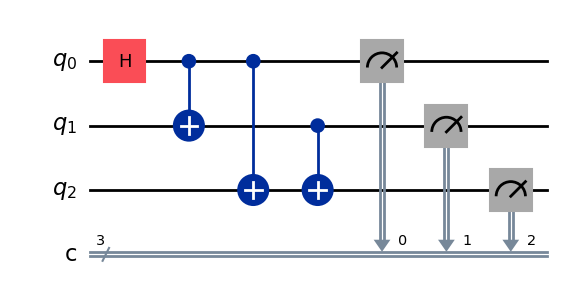

In [16]:
from qiskit import QuantumCircuit

# 1) Logical circuit
logical_qc = QuantumCircuit(3, 3)
logical_qc.h(0)
logical_qc.cx(0, 1)
logical_qc.cx(0, 2)
logical_qc.cx(1, 2)  # restored missing CNOT from original circuit
logical_qc.measure([0, 1, 2], [0, 1, 2])

logical_qc.draw('mpl')

## Step 2: Route and compile for the device

Build a routed version with two SWAPs, then transpile to the device basis gates.

Routed circuit (with two SWAPs):


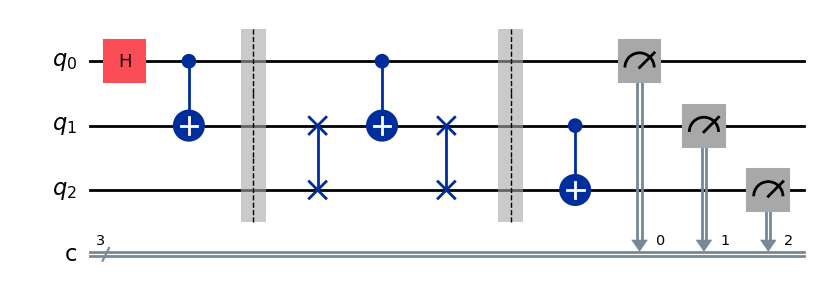

Compiled depth: 13
Gate counts: OrderedDict([('cx', 9), ('measure', 3), ('rz', 2), ('barrier', 2), ('rx', 1)])
Full compiled circuit:


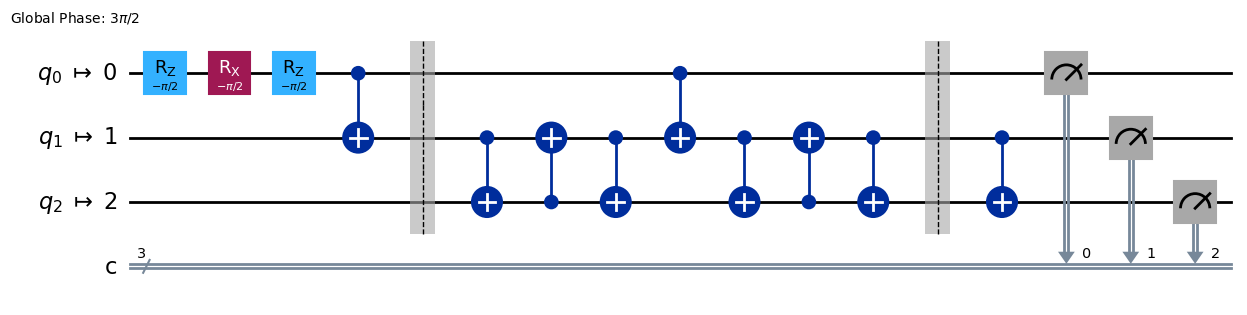

In [17]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
from IPython.display import display

# 2) Simple device model: linear connectivity 0-1-2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])
basis_gates = ['rz', 'rx', 'cx', 'measure']

# 3) Build a routed version with TWO SWAPs
routed_qc = QuantumCircuit(3, 3)
routed_qc.h(0)
routed_qc.cx(0, 1)
routed_qc.barrier()
routed_qc.swap(1, 2)
routed_qc.cx(0, 1)   # routed implementation of logical CX(0,2)
routed_qc.swap(1, 2)
routed_qc.barrier()
routed_qc.cx(1, 2)   # keep original last CNOT direction (not inverted)
routed_qc.measure([0, 1, 2], [0, 1, 2])

print('Routed circuit (with two SWAPs):')
display(routed_qc.draw('mpl'))

# Full compiled circuit for the target device (SWAP decomposed to CX)
compiled_qc = transpile(
    routed_qc,
    coupling_map=coupling_map,
    basis_gates=basis_gates,
    optimization_level=0,
    routing_method='none',
)

print('Compiled depth:', compiled_qc.depth())
print('Gate counts:', compiled_qc.count_ops())
print('Full compiled circuit:')
display(compiled_qc.draw('mpl'))

## Step 3: Simulate noisy measurements

Run ideal and noisy simulations for both logical and compiled circuits, then compare results.

Noise params: p_1q=0.0005, p_2q=0.08, readout_flip=0.02
State | Logical ideal | Logical noisy | Compiled ideal | Compiled noisy
000 | 0.497 | 0.396 | 0.498 | 0.291
001 | 0.000 | 0.033 | 0.000 | 0.073
010 | 0.000 | 0.035 | 0.000 | 0.070
011 | 0.503 | 0.404 | 0.502 | 0.292
100 | 0.000 | 0.029 | 0.000 | 0.067
101 | 0.000 | 0.037 | 0.000 | 0.070
110 | 0.000 | 0.034 | 0.000 | 0.071
111 | 0.000 | 0.032 | 0.000 | 0.065


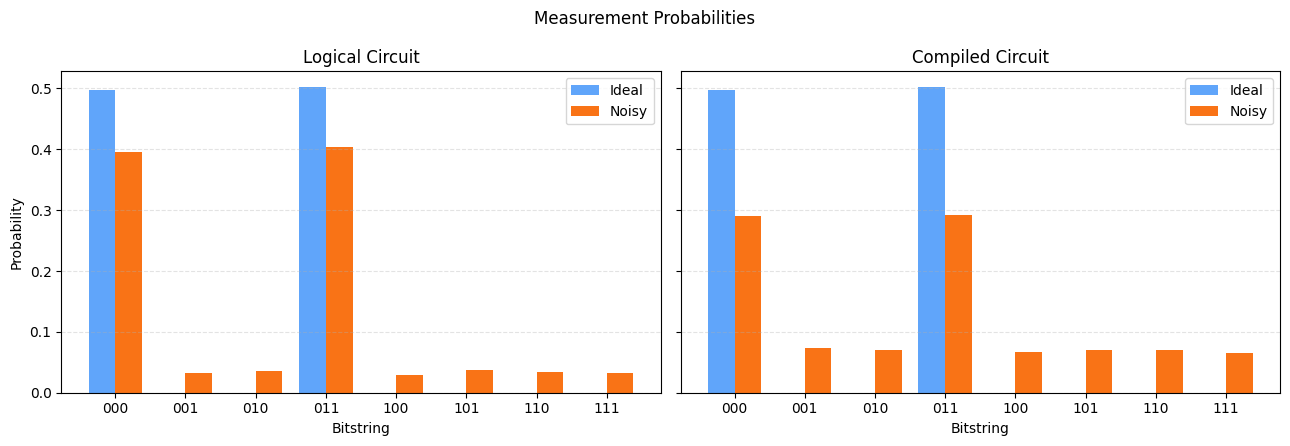

In [22]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import matplotlib.pyplot as plt
import numpy as np

p_1q = 0.0005
p_2q = 0.08
readout_flip = 0.02

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_1q, 1), ['rx', 'rz'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_2q, 2), ['cx'])
noise_model.add_all_qubit_readout_error(ReadoutError([[1 - readout_flip, readout_flip], [readout_flip, 1 - readout_flip]]))

ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise_model)
shots = 10000

# Evaluate logical and compiled circuits
logical_eval_qc = transpile(logical_qc, basis_gates=basis_gates, optimization_level=0)
compiled_eval_qc = compiled_qc

logical_ideal_counts = ideal_sim.run(logical_eval_qc, shots=shots).result().get_counts()
logical_noisy_counts = noisy_sim.run(logical_eval_qc, shots=shots).result().get_counts()
compiled_ideal_counts = ideal_sim.run(compiled_eval_qc, shots=shots).result().get_counts()
compiled_noisy_counts = noisy_sim.run(compiled_eval_qc, shots=shots).result().get_counts()

def normalize(counts):
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

logical_ideal_probs = normalize(logical_ideal_counts)
logical_noisy_probs = normalize(logical_noisy_counts)
compiled_ideal_probs = normalize(compiled_ideal_counts)
compiled_noisy_probs = normalize(compiled_noisy_counts)

# Keep original sorting style: numeric bitstring order
states = sorted(
    set(logical_ideal_probs) | set(logical_noisy_probs) | set(compiled_ideal_probs) | set(compiled_noisy_probs),
    key=lambda s: int(s, 2)
 )

li = [logical_ideal_probs.get(s, 0) for s in states]
ln = [logical_noisy_probs.get(s, 0) for s in states]
ci = [compiled_ideal_probs.get(s, 0) for s in states]
cn = [compiled_noisy_probs.get(s, 0) for s in states]

print(f'Noise params: p_1q={p_1q}, p_2q={p_2q}, readout_flip={readout_flip}')
print('State | Logical ideal | Logical noisy | Compiled ideal | Compiled noisy')
for s, a, b, c, d in zip(states, li, ln, ci, cn):
    print(f"{s} | {a:.3f} | {b:.3f} | {c:.3f} | {d:.3f}")

# Visualization: left logical, right compiled
x = np.arange(len(states))
w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].bar(x - w / 2, li, width=w, label='Ideal', color='#60a5fa')
axes[0].bar(x + w / 2, ln, width=w, label='Noisy', color='#f97316')
axes[0].set_title('Logical Circuit')
axes[0].set_xticks(x)
axes[0].set_xticklabels(states)
axes[0].set_xlabel('Bitstring')
axes[0].set_ylabel('Probability')
axes[0].grid(axis='y', linestyle='--', alpha=0.35)
axes[0].legend()

axes[1].bar(x - w / 2, ci, width=w, label='Ideal', color='#60a5fa')
axes[1].bar(x + w / 2, cn, width=w, label='Noisy', color='#f97316')
axes[1].set_title('Compiled Circuit')
axes[1].set_xticks(x)
axes[1].set_xticklabels(states)
axes[1].set_xlabel('Bitstring')
axes[1].grid(axis='y', linestyle='--', alpha=0.35)
axes[1].legend()

plt.suptitle('Measurement Probabilities')
plt.tight_layout()
plt.show()